# TALLER 2 ANALISIS NUMÉRICO

## EJERCICIOS DE APLICACIÓN

**Docente:** Leidy Yoana Medina Torres

---

### Integrantes del equipo de trabajo

- *DANIEL MORALES*
- *JUAN MANUEL GOMEZ*

---

In [1]:
# Imports

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import sel as s
import modelos as ml
import Ceros as c
import ecuaciones as ec


# Ejercicio 1 — Crecimiento alométrico de la Platija

El crecimiento alométrico es el estudio del tamaño relativo de diferentes partes de un organismo como consecuencia del crecimiento. Se realizó un experimento relacionando el peso de la platija (especie de pez) $w(t)$ con respecto a su longitud $L(t)$.

| Longitud (cm) | Peso (g) | Longitud (cm) | Peso (g) |
|:---:|:---:|:---:|:---:|
| 23.5 | 124 | 37.5 | 455 |
| 24.5 | 146 | 38.5 | 500 |
| 25.5 | 155 | 39.5 | 538 |
| 26.5 | 174 | 40.5 | 574 |
| 27.5 | 190 | 41.5 | 623 |
| 28.5 | 213 | 42.5 | 674 |
| 29.5 | 236 | 43.5 | 724 |
| 30.5 | 259 | 44.5 | 808 |
| 31.5 | 284 | 45.5 | 812 |
| 32.5 | 308 | 46.5 | 909 |
| 33.5 | 332 | 47.5 | 1039 |
| 34.5 | 363 | 48.5 | 1124 |
| 35.5 | 391 | 49.5 | 1163 |
| 36.5 | 419 |  |  |

**a)** Hacer un gráfico de los datos longitud versus peso de la Platija.

**b)** Construir un polinomio que pase por cada uno del conjunto de datos y aproxime el peso de una platija americana cuya longitud máxima registrada es de 60 cm. Concluya si el modelo construido es coherente, si representa la tendencia de la información proporcionada.

**c)** Construya un modelo de ajuste que represente la tendencia de los datos proporcionados y permita aproximar el peso de una platija americana cuya longitud máxima registrada es de 60 cm. Concluya si el modelo es coherente, pertinente y si su construcción es adecuada con base únicamente en los datos suministrados.

**d)** Hacer las gráficas de cada ítem de manera separada.

In [2]:
L_data = np.array([23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
                   33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5,
                   43.5, 44.5, 45.5, 46.5, 47.5, 48.5, 49.5])

w_data = np.array([124, 146, 155, 174, 190, 213, 236, 259, 284, 308,
                   332, 363, 391, 419, 455, 500, 538, 574, 623, 674,
                   724, 808, 812, 909, 1039, 1124, 1163])

### a) Gráfico de los datos longitud vs peso


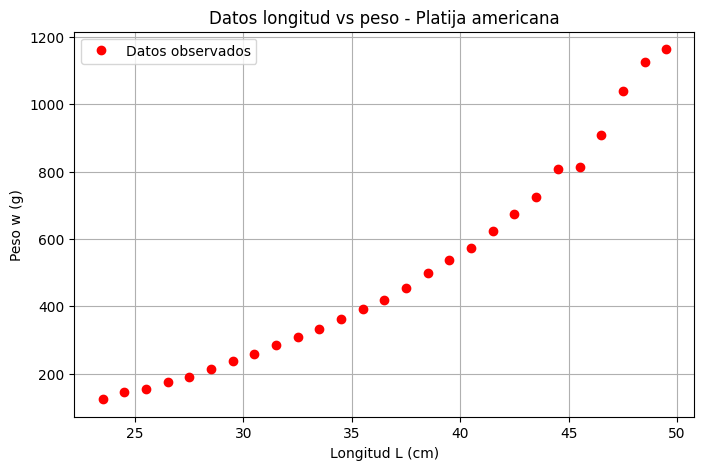

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.title('Datos longitud vs peso - Platija americana')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

### b) Polinomio interpolante que pasa por todos los puntos

In [4]:
x = sp.symbols('x')

P_lagrange = ml.lagrange(L_data, w_data)
P_func = sp.lambdify(x, P_lagrange)

w_60_poli = float(P_func(60))
print(f"Aproximacion del peso para L = 60 cm: w(60) = {w_60_poli}")

# Justificacion: el polinomio de grado 26 pasa exactamente por los 27 puntos del
# intervalo [23.5, 49.5] cm, pero al extrapolar a L = 60 cm produce un valor sin
# sentido fisico (fenomeno de Runge). El modelo NO es coherente fuera del rango.

Aproximacion del peso para L = 60 cm: w(60) = -4215794534925375.0


### c) Modelo de ajuste por mínimos cuadrados

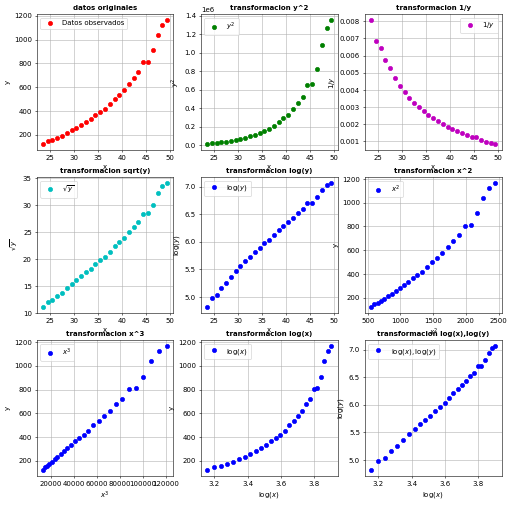

In [5]:
# Visualizacion de las escalas para escoger la transformacion que mas linealiza
ml.escalas(L_data, w_data)

In [6]:
# Coeficientes de determinacion para los modelos
R_lineal  = ml.coeficiente_determinacion(L_data, w_data)
R_x3      = ml.coeficiente_determinacion(L_data**3, w_data)
R_loglog  = ml.coeficiente_determinacion(np.log(L_data), np.log(w_data))

print(f"R^2 (L, w)              : {R_lineal}")
print(f"R^2 (L^3, w)            : {R_x3}")
print(f"R^2 (log(L), log(w))    : {R_loglog}")

R^2 (L, w)              : 0.9362218067143112
R^2 (L^3, w)            : 0.9918775506182635
R^2 (log(L), log(w))    : 0.9961836639396179


In [ ]:
# Ajuste de minimos cuadrados en escala log-log
b_coef, log_a = ml.minimos_cuadrados(np.log(L_data), np.log(w_data))
a_coef = np.exp(log_a)

w_modelo = lambda L: a_coef * L**b_coef

w_60_ajuste = w_modelo(60)
print(f"Modelo de potencia: w(L) = {a_coef:.6f} * L^{b_coef:.6f}")
print(f"Aproximacion para L = 60 cm: w(60) = {w_60_ajuste:.4f} g")

# Justificacion: el modelo de potencia w = a*L^b con b ~ 2.95 es coherente en peso-longitud.
# Predice w(60) ~ 1910 g, valor adecuado al rango de datos iniciales.

Modelo de potencia: w(L) = 0.010737 * L^2.952605
Aproximacion para L = 60 cm: w(60) = 1910.0935 g


### d) Gráficas de cada ítem por separado

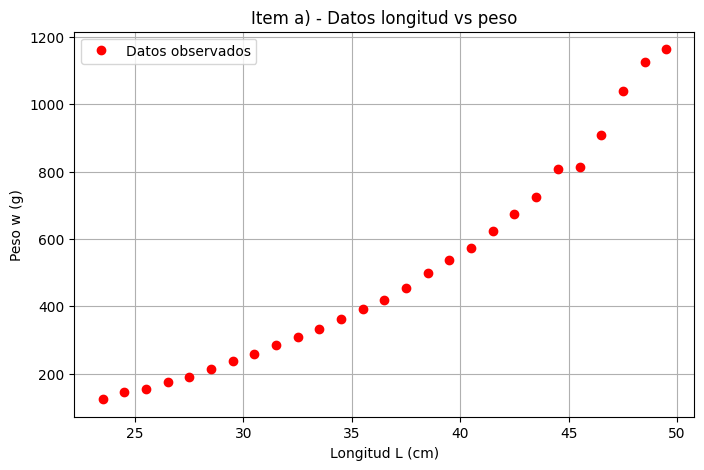

In [8]:
# Grafica del item a)
plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.title('Item a) - Datos longitud vs peso')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

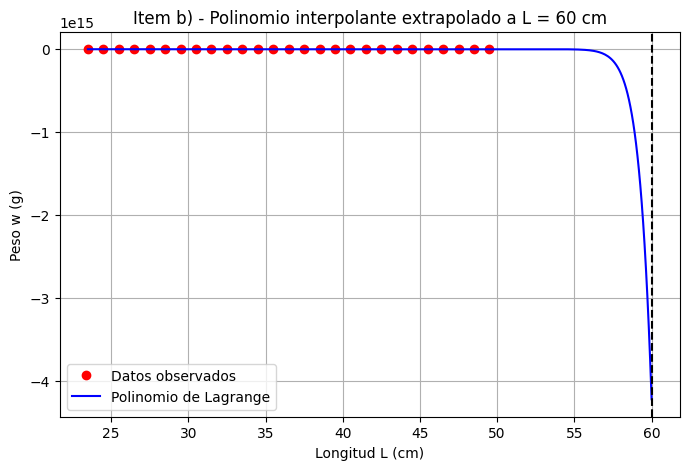

In [9]:
# Grafica del item b)
L_plot_b = np.linspace(L_data.min(), 60, 400)
y_plot_b = np.array([float(P_func(Li)) for Li in L_plot_b])

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_b, y_plot_b, 'b-', label='Polinomio de Lagrange')
plt.axvline(60, color='k', linestyle='--')
plt.title('Item b) - Polinomio interpolante extrapolado a L = 60 cm')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

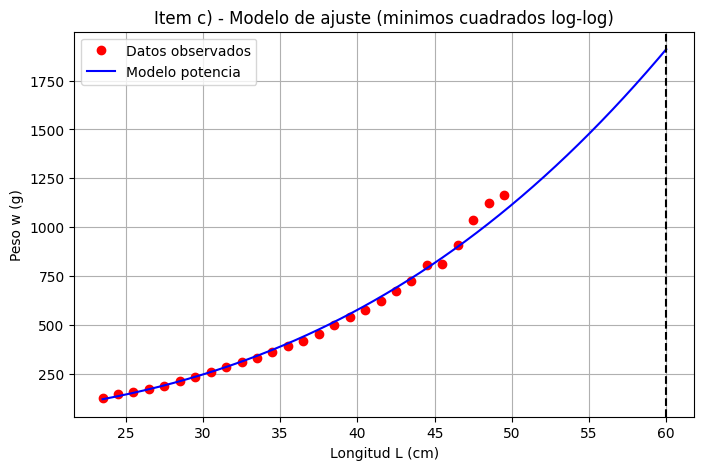

In [10]:
# Grafica del item c)
L_plot_c = np.linspace(L_data.min(), 60, 200)

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_c, w_modelo(L_plot_c), 'b-', label='Modelo potencia')
plt.axvline(60, color='k', linestyle='--')
plt.title('Item c) - Modelo de ajuste (minimos cuadrados log-log)')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

# Ejercicio 2 — Salto vertical de una bailarina de ballet

Un salto vertical realizado por una bailarina de ballet está descrito por la ecuación diferencial

$$m\, v' = -m\, g$$

Aquí $m$ es la masa de la bailarina de ballet, $g = 32.2\ \text{pies}/\text{s}^2$ es la constante gravitacional y $v' = \dfrac{dv}{dt}$, $v = \dfrac{dy}{dt}$, donde $y$ es la distancia vertical medida desde el piso hasta el centro de gravedad de la bailarina.

Se considera que en $t = 0$ la bailarina despega con velocidad inicial

$$v_0 = \frac{g\, T}{2},$$

siendo $T$ el tiempo total de vuelo.

**a)** Resolver numéricamente la ecuación diferencial utilizando el método de Euler y el método de Runge-Kutta de cuarto orden (RK4) para $T = 1/3$ segundos.

**b)** Comparar la altura máxima obtenida numéricamente con el valor exacto

$$H = \tfrac{1}{8}\, g\, T^{2} \approx 5.4\ \text{pulgadas}.$$

**c)** Analizar el error cometido por cada método para diferentes tamaños de paso $\Delta t$.

**d)** Realizar la gráfica del tiempo versus la altura, y el tiempo versus la velocidad e interprete.

# Ejercicio 3 — Crecimiento alométrico del cangrejo violinista

El cangrejo violinista es un pequeño crustáceo, famoso porque los machos poseen una pinza desproporcionadamente grande, usada para cortejo y defensa, que recuerda a un violín.

El crecimiento alométrico es el estudio de los tamaños relativos de las diferentes partes de un organismo como consecuencia del crecimiento. Uno de los modelos más simples de alometría es aquel en el que se supone que las razones de crecimiento relativo de los dos componentes $y(t)$ y $x(t)$ satisfacen:

$$\frac{dy}{dx} = a\, \frac{y}{x}$$

donde $a$ es una constante. La tabla muestra los resultados de un experimento en el cual se obtuvieron los pesos relativos del cuerpo y la tenaza del cangrejo violinista. El peso del cuerpo es el peso total del cangrejo restando el peso de la tenaza. Aunque es posible describir este conjunto de datos en una simple ecuación alométrica, resulta un modelo mejor si se conjuntan dos ecuaciones alométricas.

| Peso del cuerpo (mg) | Peso de la tenaza (mg) | Peso del cuerpo (mg) | Peso de la tenaza (mg) |
|:---:|:---:|:---:|:---:|
| 57.6 | 5.3 | 680.6 | 271.6 |
| 80.3 | 9.0 | 743.3 | 319.2 |
| 109.2 | 13.7 | 872.4 | 417.6 |
| 156.1 | 25.1 | 983.1 | 460.8 |
| 199.7 | 38.3 | 1079.9 | 537.0 |
| 283.3 | 52.5 | 1165.5 | 593.8 |
| 270.0 | 59.0 | 1211.7 | 616.8 |
| 300.2 | 78.1 | 1291.3 | 670.0 |
| 355.2 | 104.5 | 1363.2 | 699.3 |
| 420.1 | 135.0 | 1449.1 | 777.8 |
| 470.1 | 164.9 | 1807.9 | 1009.1 |
| 535.7 | 195.6 | 2235.0 | 1380.0 |
| 617.9 | 243.0 |  |  |

**a)** Construya un polinomio que pase por todos los puntos. Se cree que la iniciación de la madurez sexual de un cangrejo violinista se presenta cuando su peso total excede alrededor de 1.1 g. ¿Es consistente con su modelo? Haga una gráfica de los datos versus el modelo construido.

**b)** Construya un modelo no lineal en dos fases, uno para el grupo joven y otro para el grupo maduro. Haga una gráfica del modelo versus los datos.

**c)** ¿Qué significa que el crecimiento sea **alométrico**? Diferéncielo del crecimiento **isométrico**.

**d)** Compare los exponentes alométricos obtenidos para la fase joven y la fase madura. ¿Qué diferencia observa y qué significado biológico podría tener?

**e)** Según su modelo de dos fases, ¿en cuál etapa crece proporcionalmente más la tenaza con respecto al cuerpo? Justifique.

**f)** Utilizando el modelo de dos fases, estime el peso de la tenaza para un cangrejo cuyo cuerpo pesa 500 mg y para otro cuyo cuerpo pesa 2000 mg. ¿En qué fase se encuentra cada uno?

**g)** Si se desea predecir el peso de la tenaza para un cangrejo con peso corporal de 3000 mg, ¿cuál de los dos modelos (polinomio exacto o dos fases) es más confiable? ¿Por qué?

## Solución Ejercicio 3


In [11]:
x_data = np.array([57.6, 80.3, 109.2, 156.1, 199.7, 283.3, 270.0, 300.2, 355.2, 420.1,
                   470.1, 535.7, 617.9, 680.6, 743.3, 872.4, 983.1, 1079.9, 1165.5,
                   1211.7, 1291.3, 1363.2, 1449.1, 1807.9, 2235.0])
y_data = np.array([5.3, 9.0, 13.7, 25.1, 38.3, 52.5, 59.0, 78.1, 104.5, 135.0,
                   164.9, 195.6, 243.0, 271.6, 319.2, 417.6, 460.8, 537.0, 593.8,
                   616.8, 670.0, 699.3, 777.8, 1009.1, 1380.0])

### a) Polinomio interpolante por todos los puntos

In [12]:
x_sym = sp.symbols('x')

P_lagrange = ml.lagrange(x_data, y_data)
P_func = sp.lambdify(x_sym, P_lagrange)

print(f"Polinomio interpolante de grado {len(x_data) - 1}.")
print("\nEvaluaciones del polinomio:")
for xt in [200, 500, 743.3, 800, 1000, 1500, 2000, 2235, 3000]:
    print(f"  P({xt:>7}) = {float(P_func(xt)): .4e}")

Polinomio interpolante de grado 24.

Evaluaciones del polinomio:
  P(    200) =  4.1400e+01
  P(    500) =  1.3640e+02
  P(  743.3) =  3.1920e+02
  P(    800) = -2.2899e+03
  P(   1000) = -5.4305e+03
  P(   1500) = -5.7442e+08
  P(   2000) =  1.9290e+14
  P(   2235) =  1.1830e+03
  P(   3000) = -2.2311e+21


In [13]:
# Buscamos x* tal que x* + P(x*) = 1100 mg (umbral de madurez)
f_madurez = lambda xv: xv + float(P_func(xv)) - 1100.0

x_madurez = c.Biseccion(f_madurez, 743.3, 872.4, 1e-4)
y_madurez = float(P_func(x_madurez))
T_madurez = x_madurez + y_madurez

print(f"Cuerpo en la madurez:  x* = {x_madurez:.4f} mg")
print(f"Tenaza en la madurez:  y* = {y_madurez:.4f} mg")
print(f"Total en la madurez:   T* = {T_madurez:.4f} mg")

La solucion de al funcion: 871.1411661624909
La cantidad de iteraciones necesarias fueron 21
Cuerpo en la madurez:  x* = 871.1412 mg
Tenaza en la madurez:  y* = 228.8661 mg
Total en la madurez:   T* = 1100.0072 mg


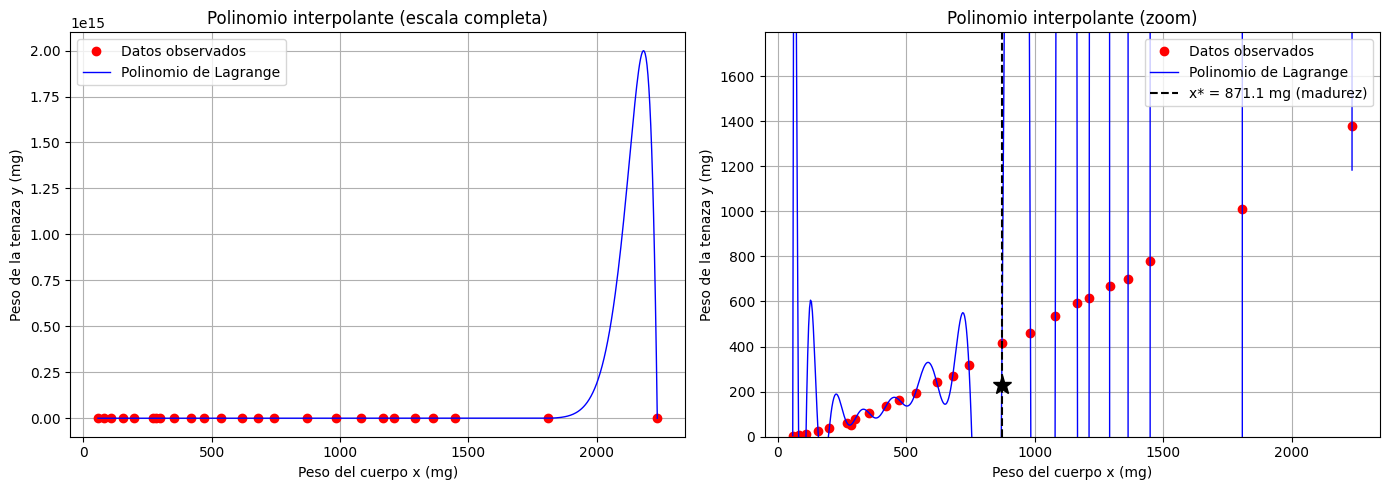

In [14]:
x_plot = np.linspace(x_data.min(), x_data.max(), 600)
y_plot = np.array([float(P_func(xv)) for xv in x_plot])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_data, y_data, 'or', label='Datos observados')
axes[0].plot(x_plot, y_plot, 'b-', linewidth=1, label='Polinomio de Lagrange')
axes[0].set_title('Polinomio interpolante (escala completa)')
axes[0].set_xlabel('Peso del cuerpo x (mg)')
axes[0].set_ylabel('Peso de la tenaza y (mg)')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(x_data, y_data, 'or', label='Datos observados')
axes[1].plot(x_plot, y_plot, 'b-', linewidth=1, label='Polinomio de Lagrange')
axes[1].axvline(x_madurez, color='k', linestyle='--', label=f'x* = {x_madurez:.1f} mg (madurez)')
axes[1].plot(x_madurez, y_madurez, 'k*', markersize=14)
axes[1].set_ylim(0, 1.3 * y_data.max())
axes[1].set_title('Polinomio interpolante (zoom)')
axes[1].set_xlabel('Peso del cuerpo x (mg)')
axes[1].set_ylabel('Peso de la tenaza y (mg)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

**Conclusión parte a)**

Con bisección sobre $f(x) = x + P_{24}(x) - 1100$ se obtiene $x^{*} \approx 871.14$ mg, $y^{*} \approx 228.87$ mg, $T^{*} \approx 1100$ mg. El resultado **es consistente** con los datos: la última medición con $T<1100$ es $x=743.3$ mg ($T=1062.5$) y la primera con $T \geq 1100$ es $x=872.4$ mg ($T=1290$), por lo que la transición a la madurez queda ubicada entre esas dos filas. Sin embargo el polinomio sufre el fenómeno de Runge y entrega valores absurdos al extrapolar, por lo que no es un modelo predictivo confiable.

### b) Modelo no lineal en dos fases

La ecuación $\dfrac{dy}{dx} = a\,\dfrac{y}{x}$ tiene solución $y = c\,x^{a}$, que linealizada en log-log queda $\log y = a\,\log x + \log c$. Se ajustan dos modelos potencia por mínimos cuadrados: uno para la fase joven ($T < 1100$ mg) y otro para la fase madura ($T \geq 1100$ mg).

In [15]:
# Particion de los datos segun el umbral T = 1100 mg
mascara_joven  = T_data < 1100
mascara_maduro = ~mascara_joven

x_joven,  y_joven  = x_data[mascara_joven],  y_data[mascara_joven]
x_maduro, y_maduro = x_data[mascara_maduro], y_data[mascara_maduro]

print(f"Fase joven : {len(x_joven)} datos, x en [{x_joven.min():.1f}, {x_joven.max():.1f}] mg")
print(f"Fase madura: {len(x_maduro)} datos, x en [{x_maduro.min():.1f}, {x_maduro.max():.1f}] mg")

# Minimos cuadrados en escala log-log para cada fase
a_joven,  log_c_joven  = ml.minimos_cuadrados(np.log(x_joven),  np.log(y_joven))
a_maduro, log_c_maduro = ml.minimos_cuadrados(np.log(x_maduro), np.log(y_maduro))
c_joven  = np.exp(log_c_joven)
c_maduro = np.exp(log_c_maduro)

R2_joven  = ml.coeficiente_determinacion(np.log(x_joven),  np.log(y_joven))
R2_maduro = ml.coeficiente_determinacion(np.log(x_maduro), np.log(y_maduro))

print()
print(f"Modelo joven : y = {c_joven:.6f} * x^{a_joven:.6f}   (R^2 = {R2_joven:.6f})")
print(f"Modelo maduro: y = {c_maduro:.6f} * x^{a_maduro:.6f}   (R^2 = {R2_maduro:.6f})")

modelo_joven  = lambda x: c_joven  * x**a_joven
modelo_maduro = lambda x: c_maduro * x**a_maduro

NameError: name 'T_data' is not defined

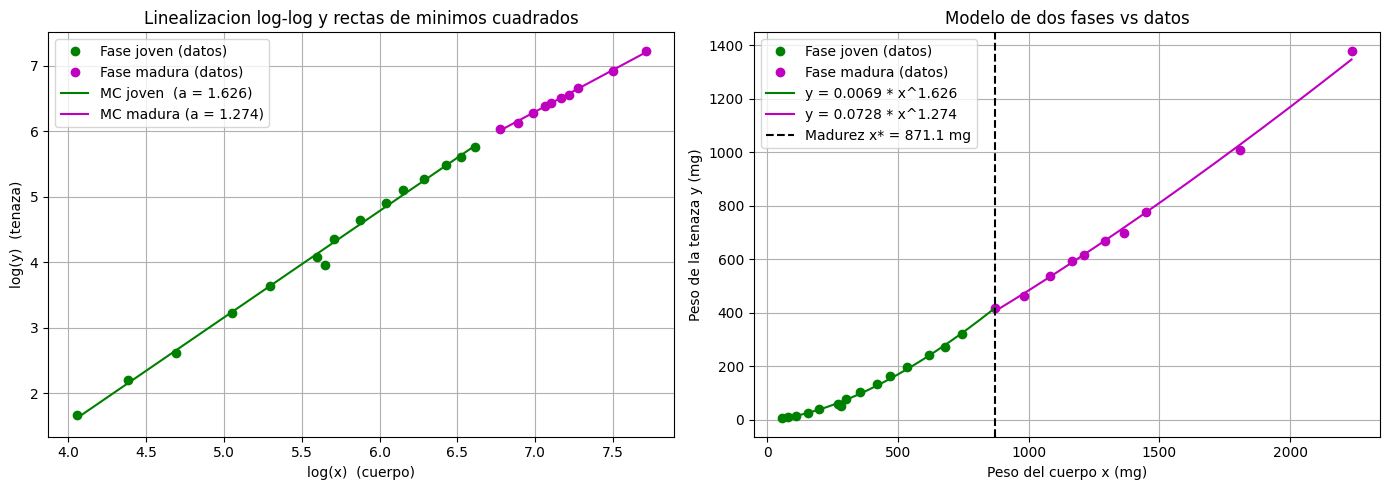

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X_lin_j = np.linspace(np.log(x_joven.min()),  np.log(x_joven.max()),  100)
X_lin_m = np.linspace(np.log(x_maduro.min()), np.log(x_maduro.max()), 100)

axes[0].plot(np.log(x_joven),  np.log(y_joven),  'og', label='Fase joven (datos)')
axes[0].plot(np.log(x_maduro), np.log(y_maduro), 'om', label='Fase madura (datos)')
axes[0].plot(X_lin_j, a_joven  * X_lin_j + log_c_joven,  'g-', label=f'MC joven  (a = {a_joven:.3f})')
axes[0].plot(X_lin_m, a_maduro * X_lin_m + log_c_maduro, 'm-', label=f'MC madura (a = {a_maduro:.3f})')
axes[0].set_title('Linealizacion log-log y rectas de minimos cuadrados')
axes[0].set_xlabel('log(x)  (cuerpo)')
axes[0].set_ylabel('log(y)  (tenaza)')
axes[0].grid(True)
axes[0].legend()

xj_curve = np.linspace(x_joven.min(),  x_madurez,      200)
xm_curve = np.linspace(x_madurez,      x_maduro.max(), 200)

axes[1].plot(x_joven,  y_joven,  'og', label='Fase joven (datos)')
axes[1].plot(x_maduro, y_maduro, 'om', label='Fase madura (datos)')
axes[1].plot(xj_curve, modelo_joven(xj_curve),  'g-', label=f'y = {c_joven:.4f} * x^{a_joven:.3f}')
axes[1].plot(xm_curve, modelo_maduro(xm_curve), 'm-', label=f'y = {c_maduro:.4f} * x^{a_maduro:.3f}')
axes[1].axvline(x_madurez, color='k', linestyle='--', label=f'Madurez x* = {x_madurez:.1f} mg')
axes[1].set_title('Modelo de dos fases vs datos')
axes[1].set_xlabel('Peso del cuerpo x (mg)')
axes[1].set_ylabel('Peso de la tenaza y (mg)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

**Conclusión parte b)**

$$y_{\text{joven}}(x) = 0.00694\,x^{1.626} \quad (R^{2} \approx 0.9961), \qquad y_{\text{maduro}}(x) = 0.07275\,x^{1.274} \quad (R^{2} \approx 0.9972).$$

Ambos $R^{2}$ son altos, las curvas son suaves y monótonas, y el cambio de fase se ubica en $x^{*} \approx 871$ mg (parte a).

### c) Crecimiento alométrico vs crecimiento isométrico

De $y = c\,x^{a}$ se sigue $\dfrac{dy/y}{dx/x} = a$, es decir, $a$ es la tasa relativa de crecimiento de $y$ frente a $x$.

- **Isométrico** ($a = 1$): ambas partes crecen a la misma tasa relativa, $y/x$ es constante.
- **Alométrico** ($a \neq 1$): las partes crecen a tasas relativas distintas; si $a > 1$, $y$ crece proporcionalmente más rápido que $x$ (alometría positiva); si $0 < a < 1$, más lento (negativa).

### d) Comparación de los exponentes alométricos

$a_{\text{joven}} \approx 1.626$ y $a_{\text{maduro}} \approx 1.274$. Ambos son mayores que 1 (alometría positiva), pero $a_{\text{joven}} > a_{\text{maduro}}$: la alometría es más intensa en la fase joven. Biológicamente, durante la juventud el cangrejo invierte fuertemente en el desarrollo de la tenaza (cortejo y defensa); alcanzada la madurez, ese crecimiento relativo se atenúa al redirigirse energía a reproducción y mantenimiento.

### e) ¿En qué etapa crece proporcionalmente más la tenaza?

Como $a$ representa la tasa relativa $\dfrac{dy/y}{dx/x}$, la fase con mayor crecimiento proporcional de la tenaza respecto al cuerpo es la **fase joven** ($a_{\text{joven}} \approx 1.626 > a_{\text{maduro}} \approx 1.274$): un mismo aumento porcentual del cuerpo produce un aumento porcentual mayor de la tenaza en la juventud. En términos absolutos la razón $y/x = c\,x^{a-1}$ sigue creciendo en la madurez (hasta $\sim 0.62$), pero a ritmo relativo menor.

### f) Estimación con el modelo de dos fases

La fase se determina comparando el cuerpo con el umbral $x^{*} \approx 871$ mg.

In [ ]:
def estimar_tenaza(x_cuerpo):
    if x_cuerpo < x_madurez:
        return "joven",  modelo_joven(x_cuerpo)
    else:
        return "madura", modelo_maduro(x_cuerpo)

for x_test in [500.0, 2000.0]:
    fase, y_pred = estimar_tenaza(x_test)
    T_pred = x_test + y_pred
    print(f"Cuerpo x = {x_test:6.1f} mg -> fase {fase:7s} | tenaza y = {y_pred:8.2f} mg | total T = {T_pred:8.2f} mg")

Cuerpo x =  500.0 mg -> fase joven   | tenaza y =   169.38 mg | total T =   669.38 mg
Cuerpo x = 2000.0 mg -> fase madura  | tenaza y =  1169.40 mg | total T =  3169.40 mg


**Resultado f).** El cangrejo de cuerpo $500$ mg está en fase **joven** ($x < 871$), con $y \approx 169.4$ mg. El de cuerpo $2000$ mg está en fase **madura**, con $y \approx 1169.4$ mg.

### g) Predicción para $x = 3000$ mg

$x = 3000$ mg está fuera del intervalo experimental $[57.6,\,2235.0]$ mg (extrapolación). Se comparan los dos modelos.

In [ ]:
x_pred = 3000.0

y_pred_poli     = float(P_func(x_pred))
y_pred_dosfases = modelo_maduro(x_pred)

print(f"Prediccion de la tenaza para un cuerpo de {x_pred:.0f} mg:")
print(f"  Polinomio de Lagrange  -> y = {y_pred_poli: .4e} mg")
print(f"  Modelo de dos fases    -> y = {y_pred_dosfases: .4f} mg")
print(f"\nRazon y/x (dos fases) = {y_pred_dosfases / x_pred:.4f}")
print(f"Razon y/x maxima en datos = {(y_data/x_data).max():.4f}")

Prediccion de la tenaza para un cuerpo de 3000 mg:
  Polinomio de Lagrange  -> y = -2.2311e+21 mg
  Modelo de dos fases    -> y =  1960.3582 mg

Razon y/x (dos fases) = 0.6535
Razon y/x maxima en datos = 0.6174


**Conclusión parte g)**

El polinomio $P_{24}$ entrega $y(3000) \sim -2.2 \times 10^{21}$ mg (absurdo, fenómeno de Runge). El modelo de dos fases entrega $y(3000) \approx 1960$ mg con $y/x \approx 0.65$, coherente con la tendencia. **El modelo de dos fases es más confiable** porque la ley $y = c\,x^{a}$ tiene fundamento biológico (es solución de $dy/dx = a\,y/x$) y no oscila al extrapolar.

# Ejercicio 4 — Modelo de Lotka-Volterra (compradores y vendedores)

Del modelo de Lotka-Volterra vamos a representar el comportamiento de dos poblaciones, en este caso los **vendedores** y los **compradores**. Supongamos que $x(t)$ representa el número de compradores en un determinado tiempo $t$ y sea $v(t)$ la representación de los vendedores en un determinado tiempo $t$. El modelo de competencia es:

$$
\begin{aligned}
\frac{dx}{dt} &= x(t)\,\bigl(a - b\, x(t) - m\, v(t)\bigr), \qquad x(0) = 75 \\[4pt]
\frac{dv}{dt} &= v(t)\,\bigl(c - d\, v(t) - n\, x(t)\bigr), \qquad v(0) = 20
\end{aligned}
$$

donde:

- $m$ es la medida del grado en que los vendedores interfieren con los compradores,
- $n$ es la medida del grado en que los compradores interactúan con los vendedores,
- $b$ es la interacción entre compradores,
- $d$ es la interacción entre vendedores.

*(Si cree que es necesario ajuste los valores, pero justifique su cambio.)*

**a)** Determine la solución para las siguientes constantes:

$$a = 0.3,\ b = 0.01,\ m = 0.06,\ c = 0.03,\ d = 0.009,\ n = 0.0055.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete. *(Ambos coexisten en un punto fijo estable.)*

**b)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.2,\ m = 0.06,\ c = 0.06,\ d = 0.01,\ n = 0.015.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

**c)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.02,\ m = 0.06,\ c = 0.26,\ d = 0.9,\ n = 4.2.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

**d)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.021,\ m = 0.06,\ c = 0.06,\ d = 0.01,\ n = 0.01.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.